# LogiSense — 01 | Data Audit, EDA & Business Intelligence Foundation

### Objective
Build a defensible analytical foundation before modelling or warehousing.

This notebook answers:
- What does the data represent?
- Is one row really one order?
- Which variables are dimensions vs measures?
- Where are quality problems, skewness and outliers?
- Which operational factors are associated with late delivery?
- What KPIs should appear in the website/Admin dashboard?
- Which columns must be excluded from ML to prevent target leakage?

### DWM topics
**Data preprocessing · data profiling · descriptive statistics · missing-value analysis · outlier analysis · correlation · feature engineering · OLAP KPI definition · data mining problem formulation**

In [10]:
# ---------- LogiSense common setup ----------
from pathlib import Path
import warnings, os, json, math, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

def find_dataset():
    candidates = [
        Path("../data/raw/E-commerce_Delivery_Shipping_Data_2026.csv"),
        Path("../data/raw/e-commerce_delivery_shipping_data_2026.csv"),
        Path("../data/E-commerce_Delivery_Shipping_Data_2026.csv"),
        Path("../E-commerce_Delivery_Shipping_Data_2026.csv"),
        Path("E-commerce_Delivery_Shipping_Data_2026.csv"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raw = Path("../data/raw")
    if raw.exists():
        csvs = list(raw.glob("*.csv"))
        if len(csvs) == 1:
            return csvs[0]
    here = Path(".")
    csvs = list(here.glob("*.csv"))
    if len(csvs) == 1:
        return csvs[0]
    raise FileNotFoundError(
        "Dataset not found. Put E-commerce_Delivery_Shipping_Data_2026.csv "
        "inside your project's data/raw/ folder."
    )

DATA_PATH = find_dataset()
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head(3))

Loaded: ..\data\raw\E-commerce_Delivery_Shipping_Data_2026.csv
Shape: (50000, 30)


,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,order_value_usd,shipping_method,carrier,distance_km,promised_delivery_days,actual_delivery_days,delivery_status,late_delivery,delivery_delay_days,shipping_cost_usd,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
0,ORD-000001,2026-11-15,CUS-002353,Small Business,Tokyo,Japan,WH-004,Toronto,Home & Kitchen,8.23,10.39,International,EagleCourier,1579.5,11,16,Delivered,Yes,5,133.10,Large,Digital Wallet,Normal,Snow,3,Yes,Late Delivery,2,25.1,Delivered
1,ORD-000002,2026-04-08,CUS-003258,Consumer,Vancouver,Canada,WH-007,Paris,Beauty,0.10,117.69,Standard,BlueRoute,1049.0,5,5,Delivered,No,0,26.95,Small,Debit Card,Normal,Cloudy,5,No,NaN,1,25.9,Delivered
2,ORD-000003,2026-01-05,CUS-001221,Consumer,Houston,United States,WH-005,London,Home & Kitchen,5.51,335.23,International,SpeedyCargo,4552.6,12,16,Delivered,Yes,4,338.62,Large,Debit Card,Low,Snow,4,Yes,Product Defect,1,31.5,Delivered


## 1. Data dictionary and structural audit

We first inspect names, data types, cardinality, missingness and uniqueness.  
This prevents a common DW mistake: designing a warehouse before understanding the source grain.

In [11]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(dropna=True),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean()*100).round(2)
}).sort_values(["missing","unique_values"], ascending=[False, False])
display(audit)

print("Duplicate complete rows:", df.duplicated().sum())
if "order_id" in df.columns:
    print("Duplicate order_id values:", df["order_id"].duplicated().sum())

,dtype,unique_values,missing,missing_%
return_reason,str,6,41375,82.75
order_id,str,50000,0,0.00
distance_km,float64,33059,0,0.00
order_value_usd,float64,24291,0,0.00
shipping_cost_usd,float64,22964,0,0.00
customer_id,str,6348,0,0.00
product_weight_kg,float64,2075,0,0.00
warehouse_processing_hours,float64,471,0,0.00
order_date,str,365,0,0.00
customer_city,str,99,0,0.00


Duplicate complete rows: 0
Duplicate order_id values: 0


## 2. Normalize dates and create warehouse-ready time attributes

The website needs **Year → Quarter → Month → Day** drill-down.  
Creating these fields once in the warehouse avoids repeatedly deriving them in every dashboard query.

In [12]:
DATE_COLS = [c for c in df.columns if "date" in c.lower()]
print("Date-like columns:", DATE_COLS)

if "order_date" in df.columns:
    df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
    df["year"] = df["order_date"].dt.year
    df["quarter"] = "Q" + df["order_date"].dt.quarter.astype("Int64").astype(str)
    df["month"] = df["order_date"].dt.month
    df["month_name"] = df["order_date"].dt.month_name()
    df["day"] = df["order_date"].dt.day
    df["day_name"] = df["order_date"].dt.day_name()
    df["week"] = df["order_date"].dt.isocalendar().week.astype("Int64")
    df["is_weekend"] = df["order_date"].dt.dayofweek >= 5
    display(df[["order_date","year","quarter","month_name","week","is_weekend"]].head())

Date-like columns: ['order_date']


,order_date,year,quarter,month_name,week,is_weekend
0,2026-11-15,2026,Q4,November,46,True
1,2026-04-08,2026,Q2,April,15,False
2,2026-01-05,2026,Q1,January,2,False
3,2026-05-29,2026,Q2,May,22,False
4,2026-02-22,2026,Q1,February,8,True


## 3. KPI layer

These measures are deliberately chosen because they can become reusable measures in the Admin Dashboard and OLAP API.

**Core KPIs:** orders, revenue, freight spend, average delivery time, average delay, late rate, return rate and customer rating.

In [13]:
def first_existing(*names):
    for n in names:
        if n in df.columns:
            return n
    return None

order_col = first_existing("order_id")
value_col = first_existing("order_value_usd","order_value","sales","revenue")
ship_col = first_existing("shipping_cost_usd","shipping_cost")
actual_col = first_existing("actual_delivery_days","delivery_days")
delay_col = first_existing("delivery_delay_days","delay_days")
rating_col = first_existing("customer_rating","rating")
late_col = first_existing("late_delivery","is_late","delivery_status")
return_col = first_existing("return_requested","returned","return_flag")

kpi = {}
kpi["Total Orders"] = df[order_col].nunique() if order_col else len(df)
if value_col: kpi["Total Order Value"] = df[value_col].sum()
if ship_col: kpi["Total Shipping Cost"] = df[ship_col].sum()
if actual_col: kpi["Avg Delivery Days"] = df[actual_col].mean()
if delay_col: kpi["Avg Delay Days"] = df[delay_col].mean()
if rating_col: kpi["Avg Customer Rating"] = df[rating_col].mean()
if late_col:
    s = df[late_col]
    if s.dtype == "object":
        kpi["Late Rate %"] = s.astype(str).str.lower().eq("yes").mean()*100
    else:
        kpi["Late Rate %"] = pd.to_numeric(s, errors="coerce").mean()*100
if return_col:
    s = df[return_col]
    if s.dtype == "object":
        kpi["Return Rate %"] = s.astype(str).str.lower().eq("yes").mean()*100
    else:
        kpi["Return Rate %"] = pd.to_numeric(s, errors="coerce").mean()*100

display(pd.Series(kpi, name="value").round(3).to_frame())

,value
Total Orders,50000.000
Total Order Value,8895855.330
Total Shipping Cost,6025776.910
Avg Delivery Days,8.346
Avg Delay Days,1.281
Avg Customer Rating,3.372
Late Rate %,NaN
Return Rate %,NaN


## 4. Dimension-wise performance comparison

A business dashboard should not only show totals. It should show **where performance differs**.

We compare carrier, warehouse, shipping method, product category, customer segment and country wherever those columns exist.

In [14]:
def normalize_binary(s):
    if s.dtype == "object":
        return s.astype(str).str.lower().isin(["yes","late","1","true"]).astype(int)
    return pd.to_numeric(s, errors="coerce")

if late_col:
    df["_late_flag"] = normalize_binary(df[late_col])
    dimensions = ["carrier","warehouse_city","warehouse_id","shipping_method",
                  "product_category","customer_segment","customer_country",
                  "weather_condition","order_priority"]
    for d in [x for x in dimensions if x in df.columns]:
        out = df.groupby(d).agg(
            orders=(order_col,"nunique") if order_col else (d,"size"),
            late_rate=("_late_flag","mean")
        ).sort_values("late_rate", ascending=False)
        out["late_rate"] *= 100
        if delay_col: out["avg_delay"] = df.groupby(d)[delay_col].mean()
        if ship_col: out["avg_shipping_cost"] = df.groupby(d)[ship_col].mean()
        if rating_col: out["avg_rating"] = df.groupby(d)[rating_col].mean()
        print(f"\n### {d}")
        display(out.sort_values("orders", ascending=False).head(15).round(2))


### carrier


,orders,late_rate,avg_delay,avg_shipping_cost,avg_rating
carrier,,,,,
BlueRoute,6435,NaN,1.43,121.38,3.30
ParcelPro,6374,NaN,1.15,118.84,3.43
SpeedyCargo,6257,NaN,1.12,122.89,3.45
SwiftShip,6233,NaN,0.99,120.19,3.50
GlobalExpress,6231,NaN,1.62,118.67,3.23
EagleCourier,6213,NaN,1.21,119.60,3.39
PrimeDelivery,6185,NaN,1.47,120.94,3.29
FastTrack Logistics,6072,NaN,1.26,121.63,3.37



### warehouse_city


,orders,late_rate,avg_delay,avg_shipping_cost,avg_rating
warehouse_city,,,,,
New York,7597,NaN,1.31,117.76,3.37
Los Angeles,7534,NaN,1.25,120.79,3.38
Chicago,5960,NaN,1.28,119.32,3.37
Toronto,4977,NaN,1.27,120.84,3.38
Berlin,4931,NaN,1.28,122.22,3.36
London,4923,NaN,1.27,120.38,3.37
Paris,3990,NaN,1.31,122.02,3.37
Sydney,3980,NaN,1.32,123.39,3.35
Dubai,3606,NaN,1.26,124.06,3.38



### warehouse_id


...

,orders,late_rate,avg_delay,avg_shipping_cost,avg_rating
customer_country,,,,,
United States,12535,NaN,1.31,119.59,3.36
United Kingdom,4984,NaN,0.91,67.88,3.52
Canada,4934,NaN,1.30,120.80,3.37
India,3974,NaN,1.81,201.05,3.19
Germany,3501,NaN,0.94,67.86,3.47
France,3031,NaN,0.89,68.90,3.53
Australia,2520,NaN,1.48,148.02,3.30
Pakistan,2039,NaN,1.80,197.09,3.20
Japan,1980,NaN,1.48,146.22,3.29



### weather_condition


,orders,late_rate,avg_delay,avg_shipping_cost,avg_rating
weather_condition,,,,,
Clear,14932,NaN,0.55,120.59,3.70
Cloudy,12582,NaN,0.79,120.81,3.54
Rain,9142,NaN,1.39,119.58,3.22
Storm,4991,NaN,2.82,122.93,2.83
Snow,4913,NaN,3.16,119.19,2.79
Extreme Heat,3440,NaN,1.05,119.99,3.38



### order_priority


,orders,late_rate,avg_delay,avg_shipping_cost,avg_rating
order_priority,,,,,
Normal,22450,NaN,1.43,120.62,3.27
High,15175,NaN,0.87,121.10,3.56
Low,7455,NaN,2.21,119.61,2.98
Urgent,4920,NaN,0.45,119.61,3.84


## 5. Distribution, skewness and outlier analysis

Outliers are not automatically deleted. In logistics, a long-distance order or expensive shipment may be a legitimate business event.

We therefore:
1. quantify outliers,
2. inspect their business context,
3. preserve them unless there is evidence of data error.

In [15]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
summary = df[num_cols].describe().T
summary["skew"] = df[num_cols].skew(numeric_only=True)
display(summary.sort_values("skew", key=lambda s: s.abs(), ascending=False).head(25).round(3))

outlier_rows = []
for c in num_cols:
    x = df[c].dropna()
    if len(x) < 10: continue
    q1,q3=x.quantile([.25,.75]); iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    n=((df[c]<lo)|(df[c]>hi)).sum()
    outlier_rows.append([c,lo,hi,n,n/len(df)*100])
display(pd.DataFrame(outlier_rows,columns=["feature","IQR_low","IQR_high","outliers","outlier_%"]).sort_values("outlier_%",ascending=False).round(2))

,count,mean,std,min,25%,50%,75%,max,skew
product_weight_kg,50000.0,2.255028,3.694952,0.1,0.32,0.93,2.61,52.19,3.996
order_value_usd,50000.0,177.917107,291.600047,10.0,28.72,76.84,173.1625,3530.73,3.522
delivery_attempts,50000.0,1.16986,0.390756,1.0,1.0,1.0,1.0,3.0,2.048
delivery_delay_days,50000.0,1.28108,1.679527,0.0,0.0,1.0,2.0,13.0,1.862
shipping_cost_usd,50000.0,120.515538,108.68003,4.05,40.64,82.97,167.4225,500.0,1.491
warehouse_processing_hours,50000.0,14.41243,9.924904,1.0,6.6,11.9,20.7,48.0,1.043
distance_km,50000.0,2496.778802,1774.633152,40.0,1086.775,2182.8,3592.475,9553.6,0.834
actual_delivery_days,50000.0,8.34594,4.644353,0.0,5.0,8.0,12.0,27.0,0.445
customer_rating,50000.0,3.37184,0.998777,1.0,3.0,3.0,4.0,5.0,-0.117
promised_delivery_days,50000.0,7.1977,3.680229,0.0,4.0,6.0,11.0,15.0,0.09


,feature,IQR_low,IQR_high,outliers,outlier_%
8,delivery_attempts,1.00,1.00,8201,16.40
1,order_value_usd,-187.94,389.83,5926,11.85
0,product_weight_kg,-3.12,6.04,4712,9.42
6,shipping_cost_usd,-149.53,357.60,2416,4.83
5,delivery_delay_days,-3.00,5.00,1638,3.28
9,warehouse_processing_hours,-14.55,41.85,1044,2.09
7,customer_rating,1.50,5.50,962,1.92
2,distance_km,-2671.77,7351.02,656,1.31
4,actual_delivery_days,-5.50,22.50,61,0.12
3,promised_delivery_days,-6.50,21.50,0,0.00


## 6. Correlation and relationship analysis

Correlation is used as a screening tool, not as proof of causality.

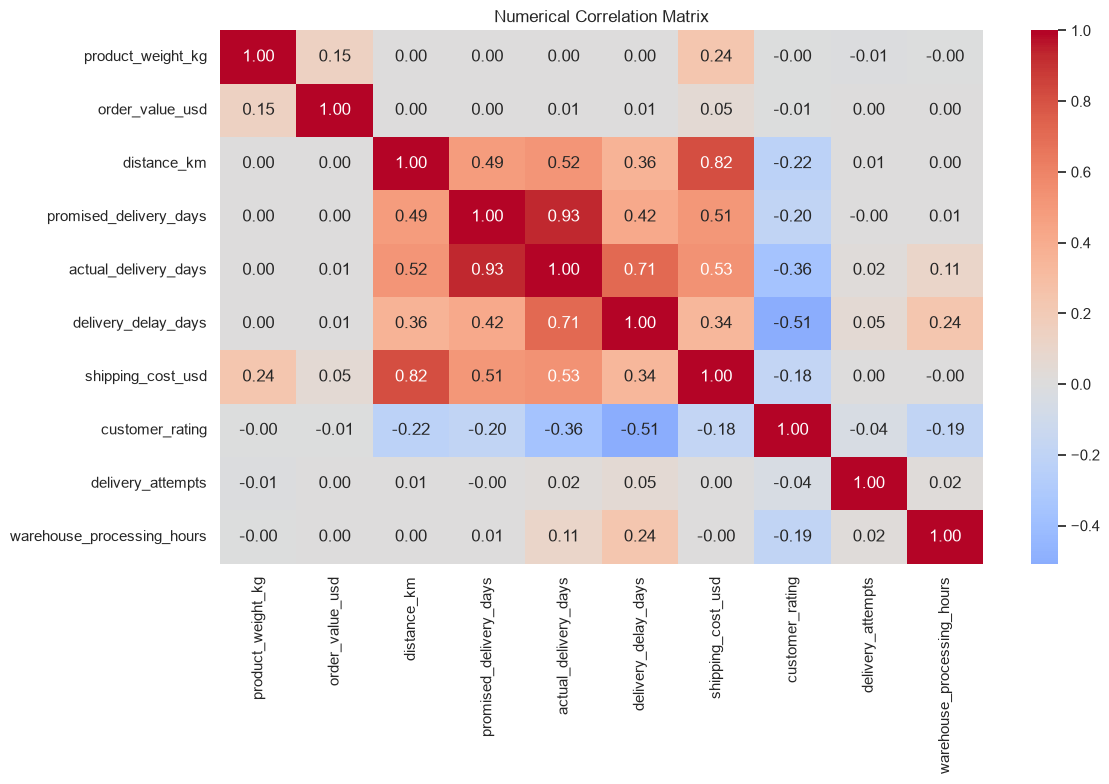

In [16]:
corr_cols = [c for c in [
    "product_weight_kg","order_value_usd","distance_km","promised_delivery_days",
    "actual_delivery_days","delivery_delay_days","shipping_cost_usd",
    "customer_rating","delivery_attempts","warehouse_processing_hours"
] if c in df.columns]
if len(corr_cols) >= 2:
    plt.figure(figsize=(12,8))
    sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Numerical Correlation Matrix")
    plt.tight_layout()
    plt.show()

## 7. Temporal trend analysis

This becomes the first major OLAP view: **roll-up from daily operations to monthly/quarterly performance**.

,year,month,month_name,orders,late_rate
0,2026,1,January,4303,NaN
1,2026,2,February,3859,NaN
2,2026,3,March,4219,NaN
3,2026,4,April,4090,NaN
4,2026,5,May,4253,NaN
5,2026,6,June,4118,NaN
6,2026,7,July,4319,NaN
7,2026,8,August,4284,NaN
8,2026,9,September,4030,NaN
9,2026,10,October,4170,NaN


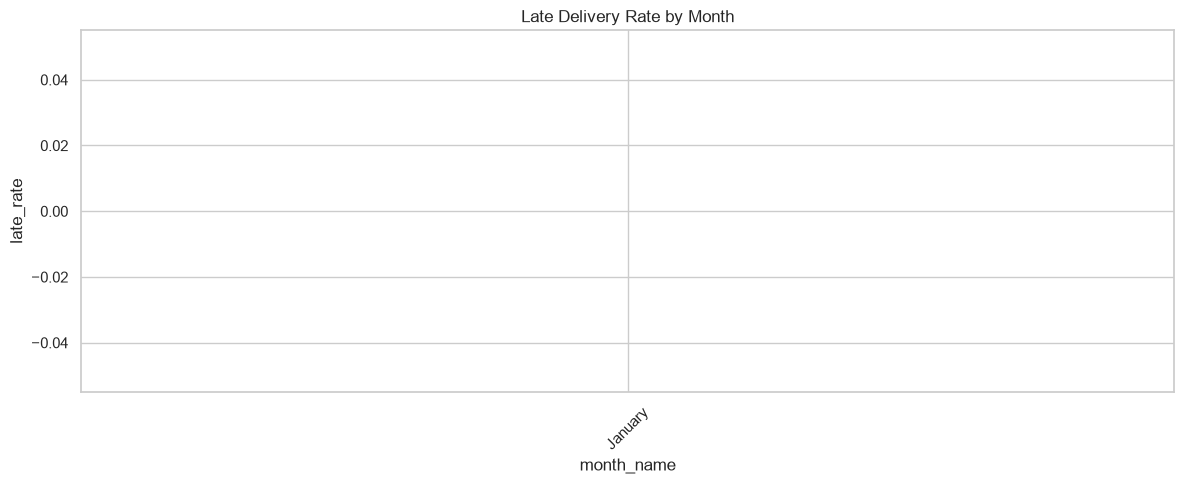

In [17]:
if "order_date" in df.columns and late_col:
    trend = df.groupby(["year","month","month_name"], as_index=False).agg(
        orders=(order_col,"nunique") if order_col else (late_col,"size"),
        late_rate=("_late_flag","mean")
    )
    trend["late_rate"] *= 100
    display(trend.round(2))

    plt.figure(figsize=(12,5))
    sns.lineplot(data=trend, x="month_name", y="late_rate", marker="o")
    plt.xticks(rotation=45)
    plt.title("Late Delivery Rate by Month")
    plt.tight_layout()
    plt.show()

## 8. ML leakage audit — critical for a defensible project

If we predict whether an order will be late **before delivery**, fields created after delivery cannot be used.

### Exclude from the predictive feature set
- `delivery_delay_days`
- `actual_delivery_days`
- final `delivery_status`
- final `tracking_status`
- any post-delivery return outcome

This is an important point to explain in the viva: **high accuracy caused by target leakage is not a successful model.**

In [18]:
leakage_keywords = ["actual","delay","late","status","tracking","delivered","return_reason"]
leakage_candidates = [c for c in df.columns if any(k in c.lower() for k in leakage_keywords)]
print("Potential outcome/post-event fields:")
print(leakage_candidates)

Potential outcome/post-event fields:
['actual_delivery_days', 'delivery_status', 'late_delivery', 'delivery_delay_days', 'return_reason', 'tracking_status', '_late_flag']


## 9. Final analytical questions

These questions drive the rest of LogiSense:

**Descriptive:** What happened?  
**Diagnostic:** Where and under which conditions do delays concentrate?  
**Predictive:** Which future orders are at risk of being late?  
**Prescriptive:** Which carrier/shipping combination should operations consider?  
**Customer analytics:** What behavioral segments exist?  
**Pattern mining:** Which operational conditions frequently co-occur?

**Next:** build a Star Schema and ETL pipeline around these questions.